In [5]:
import sys

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Python executable:
c:\Users\Neha\AppData\Local\Programs\Python\Python314\python.exe

Python version:
3.14.7 (tags/v3.14.7:823f032, Aug  5 2026, 10:51:32) [MSC v.1944 64 bit (AMD64)]


In [1]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\Neha\Desktop\AI-Supply-Chain-Intelligence\.venv\Scripts\python.exe
3.14.7 (tags/v3.14.7:823f032, Aug  5 2026, 10:51:32) [MSC v.1944 64 bit (AMD64)]


In [2]:
import sys

print(sys.executable)

c:\Users\Neha\AppData\Local\Programs\Python\Python314\python.exe


In [2]:
import pandas as pd
import numpy as np

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Pandas: 3.0.6
NumPy: 2.5.3


In [3]:
import pandas as pd

file_path = "../data/raw/DataCoSupplyChainDataset.csv"

df = pd.read_csv(
    file_path,
    encoding="latin1"
)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 180519
Columns: 53


In [4]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [5]:
print("Number of columns:", len(df.columns))

for i, column in enumerate(df.columns, start=1):
    print(i, "->", column)

Number of columns: 53
1 -> Type
2 -> Days for shipping (real)
3 -> Days for shipment (scheduled)
4 -> Benefit per order
5 -> Sales per customer
6 -> Delivery Status
7 -> Late_delivery_risk
8 -> Category Id
9 -> Category Name
10 -> Customer City
11 -> Customer Country
12 -> Customer Email
13 -> Customer Fname
14 -> Customer Id
15 -> Customer Lname
16 -> Customer Password
17 -> Customer Segment
18 -> Customer State
19 -> Customer Street
20 -> Customer Zipcode
21 -> Department Id
22 -> Department Name
23 -> Latitude
24 -> Longitude
25 -> Market
26 -> Order City
27 -> Order Country
28 -> Order Customer Id
29 -> order date (DateOrders)
30 -> Order Id
31 -> Order Item Cardprod Id
32 -> Order Item Discount
33 -> Order Item Discount Rate
34 -> Order Item Id
35 -> Order Item Product Price
36 -> Order Item Profit Ratio
37 -> Order Item Quantity
38 -> Sales
39 -> Order Item Total
40 -> Order Profit Per Order
41 -> Order Region
42 -> Order State
43 -> Order Status
44 -> Order Zipcode
45 -> Product

In [6]:
print(df.columns.tolist())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping date (DateOrde

In [ ]:
#Our prediction problem

#We'll define the business problem as:Predict whether an order is at risk of late delivery using information available around the time the order is placed.

#Our target is:Late_delivery_risk This makes the ML problem a binary classification problem.

In [7]:
df["Late_delivery_risk"].value_counts()

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

In [ ]:
df["Late_delivery_risk"].value_counts(normalize=True) * 100
#tells us whether the classes are balanced

Late_delivery_risk
1    54.829132
0    45.170868
Name: proportion, dtype: float64

In [9]:
print("Late Delivery Risk Distribution:")
print(df["Late_delivery_risk"].value_counts())

print("\nPercentage:")
print(df["Late_delivery_risk"].value_counts(normalize=True) * 100)

Late Delivery Risk Distribution:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Percentage:
Late_delivery_risk
1    54.829132
0    45.170868
Name: proportion, dtype: float64


In [10]:
#missing values 
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

Product Description    180519
Order Zipcode          155679
Customer Lname              8
Customer Zipcode            3
dtype: int64


In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
print(df["order date (DateOrders)"].head())
print(df["order date (DateOrders)"].dtype)

0    1/31/2018 22:56
1    1/13/2018 12:27
2    1/13/2018 12:06
3    1/13/2018 11:45
4    1/13/2018 11:24
Name: order date (DateOrders), dtype: str
str


In [13]:
print("Shipping Modes:")
print(df["Shipping Mode"].value_counts())

print("\nCustomer Segments:")
print(df["Customer Segment"].value_counts())

print("\nMarkets:")
print(df["Market"].value_counts())

Shipping Modes:
Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

Customer Segments:
Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64

Markets:
Market
LATAM           51594
Europe          50252
Pacific Asia    41260
USCA            25799
Africa          11614
Name: count, dtype: int64


In [14]:
leakage_check = [
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Delivery Status",
    "Late_delivery_risk",
    "Order Status",
    "shipping date (DateOrders)"
]

for col in leakage_check:
    print(f"\n--- {col} ---")
    print("Data type:", df[col].dtype)
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts().head(10))


--- Days for shipping (real) ---
Data type: int64
Unique values: 7
Days for shipping (real)
2    56618
3    28765
6    28723
4    28513
5    28163
0     5080
1     4657
Name: count, dtype: int64

--- Days for shipment (scheduled) ---
Data type: int64
Unique values: 4
Days for shipment (scheduled)
4    107752
2     35216
1     27814
0      9737
Name: count, dtype: int64

--- Delivery Status ---
Data type: str
Unique values: 4
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

--- Late_delivery_risk ---
Data type: int64
Unique values: 2
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

--- Order Status ---
Data type: str
Unique values: 9
Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893

In [15]:
df["order date (DateOrders)"] = pd.to_datetime(
    df["order date (DateOrders)"],
    errors="coerce"
)

print("Earliest order:", df["order date (DateOrders)"].min())
print("Latest order:", df["order date (DateOrders)"].max())
print("Invalid dates:", df["order date (DateOrders)"].isna().sum())

Earliest order: 2015-01-01 00:00:00
Latest order: 2018-01-31 23:38:00
Invalid dates: 0


In [16]:
print(
    pd.crosstab(
        df["Days for shipping (real)"],
        df["Late_delivery_risk"],
        normalize="index"
    ).round(3)
)

Late_delivery_risk            0      1
Days for shipping (real)              
0                         1.000  0.000
1                         0.044  0.956
2                         0.532  0.468
3                         0.765  0.235
4                         0.763  0.237
5                         0.041  0.959
6                         0.043  0.957


In [17]:
print(
    pd.crosstab(
        df["Days for shipment (scheduled)"],
        df["Late_delivery_risk"],
        normalize="index"
    ).round(3)
)

Late_delivery_risk                 0      1
Days for shipment (scheduled)              
0                              0.543  0.457
1                              0.047  0.953
2                              0.234  0.766
4                              0.619  0.381


In [18]:
print(df["Delivery Status"].unique())

<StringArray>
['Advance shipping', 'Late delivery', 'Shipping on time', 'Shipping canceled']
Length: 4, dtype: str


In [19]:
print(df["Delivery Status"].value_counts())

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64


In [20]:
print(df["Order Status"].unique())
print(df["Order Status"].value_counts())

<StringArray>
[       'COMPLETE',         'PENDING',          'CLOSED', 'PENDING_PAYMENT',
        'CANCELED',      'PROCESSING', 'SUSPECTED_FRAUD',         'ON_HOLD',
  'PAYMENT_REVIEW']
Length: 9, dtype: str
Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64


In [21]:
ml_features = [
    "Type",
    "Days for shipment (scheduled)",
    "Category Id",
    "Category Name",
    "Customer Segment",
    "Department Id",
    "Department Name",
    "Market",
    "Order City",
    "Order Country",
    "Order Region",
    "Order State",
    "Product Card Id",
    "Product Category Id",
    "Product Name",
    "Product Price",
    "Product Status",
    "Order Item Discount",
    "Order Item Discount Rate",
    "Order Item Quantity",
    "Order Item Product Price",
    "Shipping Mode",
    "order date (DateOrders)"
]

target = "Late_delivery_risk"

print("Number of candidate ML features:", len(ml_features))
print("\nFeatures:")
for feature in ml_features:
    print("-", feature)

print("\nTarget:", target)

Number of candidate ML features: 23

Features:
- Type
- Days for shipment (scheduled)
- Category Id
- Category Name
- Customer Segment
- Department Id
- Department Name
- Market
- Order City
- Order Country
- Order Region
- Order State
- Product Card Id
- Product Category Id
- Product Name
- Product Price
- Product Status
- Order Item Discount
- Order Item Discount Rate
- Order Item Quantity
- Order Item Product Price
- Shipping Mode
- order date (DateOrders)

Target: Late_delivery_risk


In [22]:
df["order date (DateOrders)"] = pd.to_datetime(
    df["order date (DateOrders)"],
    errors="coerce"
)

df["order_year"] = df["order date (DateOrders)"].dt.year
df["order_month"] = df["order date (DateOrders)"].dt.month
df["order_day"] = df["order date (DateOrders)"].dt.day
df["order_day_of_week"] = df["order date (DateOrders)"].dt.dayofweek

print(df[
    [
        "order date (DateOrders)",
        "order_year",
        "order_month",
        "order_day",
        "order_day_of_week"
    ]
].head())

  order date (DateOrders)  order_year  order_month  order_day  \
0     2018-01-31 22:56:00        2018            1         31   
1     2018-01-13 12:27:00        2018            1         13   
2     2018-01-13 12:06:00        2018            1         13   
3     2018-01-13 11:45:00        2018            1         13   
4     2018-01-13 11:24:00        2018            1         13   

   order_day_of_week  
0                  2  
1                  5  
2                  5  
3                  5  
4                  5  


In [23]:
import os

os.makedirs("../database", exist_ok=True)

print("Database folder created.")

Database folder created.


In [24]:
import sqlite3

db_path = "../database/supply_chain.db"

conn = sqlite3.connect(db_path)

print("Database connected successfully!")
print("Database:", db_path)

Database connected successfully!
Database: ../database/supply_chain.db


In [25]:
customers = df[
    [
        "Customer Id",
        "Customer Segment",
        "Customer City",
        "Customer State",
        "Customer Country",
        "Market"
    ]
].drop_duplicates(subset=["Customer Id"]).copy()

customers.columns = [
    "customer_id",
    "customer_segment",
    "customer_city",
    "customer_state",
    "customer_country",
    "market"
]

customers.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

print("Customers table created:", len(customers), "records")

Customers table created: 20652 records


In [26]:
products = df[
    [
        "Product Card Id",
        "Product Name",
        "Category Id",
        "Category Name",
        "Department Id",
        "Department Name",
        "Product Price",
        "Product Status"
    ]
].drop_duplicates(subset=["Product Card Id"]).copy()

products.columns = [
    "product_id",
    "product_name",
    "category_id",
    "category_name",
    "department_id",
    "department_name",
    "product_price",
    "product_status"
]

products.to_sql(
    "products",
    conn,
    if_exists="replace",
    index=False
)

print("Products table created:", len(products), "records")

Products table created: 118 records


In [27]:
orders = df[
    [
        "Order Id",
        "Customer Id",
        "Type",
        "order date (DateOrders)",
        "Market",
        "Order City",
        "Order Country",
        "Order Region",
        "Order State",
        "Shipping Mode",
        "Days for shipment (scheduled)",
        "Late_delivery_risk"
    ]
].drop_duplicates(subset=["Order Id"]).copy()

orders.columns = [
    "order_id",
    "customer_id",
    "order_type",
    "order_date",
    "market",
    "order_city",
    "order_country",
    "order_region",
    "order_state",
    "shipping_mode",
    "scheduled_shipping_days",
    "late_delivery_risk"
]

orders.to_sql(
    "orders",
    conn,
    if_exists="replace",
    index=False
)

print("Orders table created:", len(orders), "records")

Orders table created: 65752 records


In [28]:
order_items = df[
    [
        "Order Item Id",
        "Order Id",
        "Product Card Id",
        "Order Item Quantity",
        "Order Item Product Price",
        "Order Item Discount",
        "Order Item Discount Rate",
        "Order Item Total",
        "Order Profit Per Order",
        "Order Item Profit Ratio"
    ]
].copy()

order_items.columns = [
    "order_item_id",
    "order_id",
    "product_id",
    "quantity",
    "product_price",
    "discount",
    "discount_rate",
    "item_total",
    "profit_per_order",
    "profit_ratio"
]

order_items.to_sql(
    "order_items",
    conn,
    if_exists="replace",
    index=False
)

print("Order items table created:", len(order_items), "records")

Order items table created: 180519 records


In [29]:
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name
    """,
    conn
)

tables

,name
0,customers
1,order_items
2,orders
3,products


In [30]:
for table in ["customers", "products", "orders", "order_items"]:
    result = pd.read_sql_query(
        f"SELECT COUNT(*) AS row_count FROM {table}",
        conn
    )
    
    print(table, "->", result.iloc[0]["row_count"])

customers -> 20652
products -> 118
orders -> 65752
order_items -> 180519


In [ ]:
query = """
SELECT
    shipping_mode,
    COUNT(*) AS total_orders,
    SUM(late_delivery_risk) AS late_orders,
    ROUND(
        100.0 * SUM(late_delivery_risk) / COUNT(*),
        2
    ) AS late_delivery_rate
FROM orders
GROUP BY shipping_mode
ORDER BY late_delivery_rate DESC;
"""

shipping_analysis = pd.read_sql_query(query, conn)

shipping_analysis
#Which shipping modes have the highest late-delivery rate?

,shipping_mode,total_orders,late_orders,late_delivery_rate
0,First Class,10079,9602,95.27
1,Second Class,12778,9803,76.72
2,Same Day,3571,1648,46.15
3,Standard Class,39324,14995,38.13


In [32]:
query = """
SELECT
    market,
    COUNT(*) AS total_orders,
    SUM(late_delivery_risk) AS late_orders,
    ROUND(
        100.0 * SUM(late_delivery_risk) / COUNT(*),
        2
    ) AS late_delivery_rate
FROM orders
GROUP BY market
ORDER BY late_delivery_rate DESC;
"""

market_analysis = pd.read_sql_query(query, conn)

market_analysis

,market,total_orders,late_orders,late_delivery_rate
0,Pacific Asia,17577,9720,55.30
1,Europe,18561,10199,54.95
2,USCA,8579,4704,54.83
3,LATAM,17181,9339,54.36
4,Africa,3854,2086,54.13


In [33]:
query = """
SELECT
    o.order_id,
    o.customer_id,
    o.order_type,
    o.order_date,
    o.market,
    o.order_city,
    o.order_country,
    o.order_region,
    o.order_state,
    o.shipping_mode,
    o.scheduled_shipping_days,

    c.customer_segment,

    oi.order_item_id,
    oi.product_id,
    oi.quantity,
    oi.product_price,
    oi.discount,
    oi.discount_rate,

    p.category_id,
    p.category_name,
    p.department_id,
    p.department_name,
    p.product_name,
    p.product_status,

    o.late_delivery_risk

FROM orders o

LEFT JOIN customers c
    ON o.customer_id = c.customer_id

LEFT JOIN order_items oi
    ON o.order_id = oi.order_id

LEFT JOIN products p
    ON oi.product_id = p.product_id
"""

ml_sql_df = pd.read_sql_query(query, conn)

print("Rows:", ml_sql_df.shape[0])
print("Columns:", ml_sql_df.shape[1])

ml_sql_df.head()

Rows: 180519
Columns: 25


,order_id,customer_id,order_type,order_date,market,order_city,order_country,order_region,order_state,shipping_mode,...,product_price,discount,discount_rate,category_id,category_name,department_id,department_name,product_name,product_status,late_delivery_risk
0,77202,20755,DEBIT,2018-01-31 22:56:00,Pacific Asia,Bekasi,Indonesia,Southeast Asia,Java Occidental,Standard Class,...,327.75,13.110000,0.04,73,Sporting Goods,2,Fitness,Smart watch,0,0
1,75939,19492,TRANSFER,2018-01-13 12:27:00,Pacific Asia,Bikaner,India,South Asia,Rajastán,Standard Class,...,327.75,16.389999,0.05,73,Sporting Goods,2,Fitness,Smart watch,0,1
2,75938,19491,CASH,2018-01-13 12:06:00,Pacific Asia,Bikaner,India,South Asia,Rajastán,Standard Class,...,327.75,18.030001,0.06,73,Sporting Goods,2,Fitness,Smart watch,0,0
3,75937,19490,DEBIT,2018-01-13 11:45:00,Pacific Asia,Townsville,Australia,Oceania,Queensland,Standard Class,...,327.75,22.940001,0.07,73,Sporting Goods,2,Fitness,Smart watch,0,0
4,75936,19489,PAYMENT,2018-01-13 11:24:00,Pacific Asia,Townsville,Australia,Oceania,Queensland,Standard Class,...,327.75,29.500000,0.09,73,Sporting Goods,2,Fitness,Smart watch,0,0


In [34]:
print("Missing customer segments:",
      ml_sql_df["customer_segment"].isna().sum())

print("Missing product names:",
      ml_sql_df["product_name"].isna().sum())

print("Missing target:",
      ml_sql_df["late_delivery_risk"].isna().sum())

Missing customer segments: 0
Missing product names: 0
Missing target: 0


In [35]:
for table in ["customers", "products", "orders", "order_items"]:
    result = pd.read_sql_query(
        f"SELECT COUNT(*) AS row_count FROM {table}",
        conn
    )
    print(table, "->", result.iloc[0]["row_count"])

customers -> 20652
products -> 118
orders -> 65752
order_items -> 180519


In [36]:
order_ml_query = """
SELECT
    o.order_id,
    o.customer_id,
    o.order_type,
    o.order_date,
    o.market,
    o.order_city,
    o.order_country,
    o.order_region,
    o.order_state,
    o.shipping_mode,
    o.scheduled_shipping_days,

    c.customer_segment,

    COUNT(DISTINCT oi.order_item_id) AS item_count,
    COUNT(DISTINCT oi.product_id) AS distinct_product_count,
    SUM(oi.quantity) AS total_quantity,
    AVG(oi.product_price) AS avg_product_price,
    SUM(oi.discount) AS total_discount,
    AVG(oi.discount_rate) AS avg_discount_rate,

    o.late_delivery_risk

FROM orders o

LEFT JOIN customers c
    ON o.customer_id = c.customer_id

LEFT JOIN order_items oi
    ON o.order_id = oi.order_id

GROUP BY
    o.order_id,
    o.customer_id,
    o.order_type,
    o.order_date,
    o.market,
    o.order_city,
    o.order_country,
    o.order_region,
    o.order_state,
    o.shipping_mode,
    o.scheduled_shipping_days,
    c.customer_segment,
    o.late_delivery_risk
"""

order_ml_df = pd.read_sql_query(order_ml_query, conn)

print("Rows:", order_ml_df.shape[0])
print("Columns:", order_ml_df.shape[1])

Rows: 65752
Columns: 19


In [37]:
print("Unique orders:", order_ml_df["order_id"].nunique())
print("Total rows:", len(order_ml_df))

print(
    "Duplicate order IDs:",
    order_ml_df["order_id"].duplicated().sum()
)

Unique orders: 65752
Total rows: 65752
Duplicate order IDs: 0


In [38]:
print(order_ml_df["late_delivery_risk"].value_counts())
print(
    order_ml_df["late_delivery_risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

late_delivery_risk
1    36048
0    29704
Name: count, dtype: int64
late_delivery_risk
1    54.82
0    45.18
Name: proportion, dtype: float64


In [39]:
order_ml_df["order_date"] = pd.to_datetime(
    order_ml_df["order_date"],
    errors="coerce"
)

order_ml_df["order_year"] = order_ml_df["order_date"].dt.year
order_ml_df["order_month"] = order_ml_df["order_date"].dt.month
order_ml_df["order_day_of_week"] = order_ml_df["order_date"].dt.dayofweek

In [40]:
print(order_ml_df[
    [
        "order_date",
        "order_year",
        "order_month",
        "order_day_of_week"
    ]
].head())

           order_date  order_year  order_month  order_day_of_week
0 2015-01-01 00:00:00        2015            1                  3
1 2015-01-01 00:21:00        2015            1                  3
2 2015-01-01 01:03:00        2015            1                  3
3 2015-01-01 01:24:00        2015            1                  3
4 2015-01-01 02:06:00        2015            1                  3


In [41]:
model_features = [
    "order_type",
    "market",
    "order_city",
    "order_country",
    "order_region",
    "order_state",
    "shipping_mode",
    "scheduled_shipping_days",
    "customer_segment",
    "item_count",
    "distinct_product_count",
    "total_quantity",
    "avg_product_price",
    "total_discount",
    "avg_discount_rate",
    "order_year",
    "order_month",
    "order_day_of_week"
]

target = "late_delivery_risk"

X = order_ml_df[model_features].copy()
y = order_ml_df[target].copy()

print("Features:", X.shape)
print("Target:", y.shape)

Features: (65752, 18)
Target: (65752,)


In [42]:
missing_features = X.isnull().sum()

print(
    missing_features[missing_features > 0]
    .sort_values(ascending=False)
)

Series([], dtype: int64)


In [43]:
categorical_columns = X.select_dtypes(
    include=["object", "string"]
).columns

for col in categorical_columns:
    print(f"{col}: {X[col].nunique()} unique values")

order_type: 4 unique values
market: 5 unique values
order_city: 3597 unique values
order_country: 164 unique values
order_region: 23 unique values
order_state: 1089 unique values
shipping_mode: 4 unique values
customer_segment: 3 unique values


In [44]:
numeric_columns = X.select_dtypes(
    include=["number"]
).columns

X[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
scheduled_shipping_days,65752.0,2.934223,1.374790,0.00,2.000000,4.000000,4.000000,4.00
item_count,65752.0,2.745453,1.478363,1.00,1.000000,3.000000,4.000000,5.00
distinct_product_count,65752.0,2.429782,1.257508,1.00,1.000000,2.000000,3.000000,5.00
total_quantity,65752.0,5.841328,4.169632,1.00,2.000000,5.000000,9.000000,24.00
avg_product_price,65752.0,154.289872,148.704953,9.99,68.986002,126.653337,196.232506,1500.00
total_discount,65752.0,56.734067,46.584295,0.00,20.000000,47.390000,82.390002,681.50
avg_discount_rate,65752.0,0.101711,0.051820,0.00,0.065000,0.100000,0.135000,0.25
order_year,65752.0,2016.079207,0.879411,2015.00,2015.000000,2016.000000,2017.000000,2018.00
order_month,65752.0,6.418649,3.556108,1.00,3.000000,6.000000,10.000000,12.00
order_day_of_week,65752.0,3.001065,1.998889,0.00,1.000000,3.000000,5.000000,6.00


In [45]:
print(
    order_ml_df["order_year"]
    .value_counts()
    .sort_index()
)
print(
    order_ml_df.groupby("order_year")["late_delivery_risk"]
    .agg(["count", "mean"])
)

order_year
2015    20904
2016    20859
2017    21866
2018     2123
Name: count, dtype: int64
            count      mean
order_year                 
2015        20904  0.546833
2016        20859  0.551177
2017        21866  0.545367
2018         2123  0.562883


In [46]:
train_mask = order_ml_df["order_year"] < 2018
test_mask = order_ml_df["order_year"] == 2018

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training samples: 63629
Test samples: 2123

Training target distribution:
late_delivery_risk
1    54.78
0    45.22
Name: proportion, dtype: float64

Test target distribution:
late_delivery_risk
1    56.29
0    43.71
Name: proportion, dtype: float64


In [47]:
categorical_features = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumeric features:")
print(numeric_features)

Categorical features:
['order_type', 'market', 'order_city', 'order_country', 'order_region', 'order_state', 'shipping_mode', 'customer_segment']

Numeric features:
['scheduled_shipping_days', 'item_count', 'distinct_product_count', 'total_quantity', 'avg_product_price', 'total_discount', 'avg_discount_rate', 'order_year', 'order_month', 'order_day_of_week']


In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=5
            ),
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features
        )
    ]
)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)

print("Pipeline created successfully.")

Pipeline created successfully.


In [49]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [50]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.6929
Precision: 0.8075
Recall   : 0.5967
F1 Score : 0.6862
ROC-AUC  : 0.7546

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.82      0.70       928
           1       0.81      0.60      0.69      1195

    accuracy                           0.69      2123
   macro avg       0.71      0.71      0.69      2123
weighted avg       0.72      0.69      0.69      2123



In [51]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=15,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest pipeline created.")

Random Forest pipeline created.


In [52]:
random_forest_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [53]:
rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, rf_pred), 4))
print("Precision:", round(precision_score(y_test, rf_pred), 4))
print("Recall   :", round(recall_score(y_test, rf_pred), 4))
print("F1 Score :", round(f1_score(y_test, rf_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, rf_prob), 4))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Accuracy : 0.6891
Precision: 0.7996
Recall   : 0.5975
F1 Score : 0.6839
ROC-AUC  : 0.7535

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.81      0.69       928
           1       0.80      0.60      0.68      1195

    accuracy                           0.69      2123
   macro avg       0.70      0.70      0.69      2123
weighted avg       0.72      0.69      0.69      2123



In [54]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(X_train, y_train)

dummy_pred = dummy_model.predict(X_test)

print("Baseline Accuracy:",
      round(accuracy_score(y_test, dummy_pred), 4))

print(
    classification_report(
        y_test,
        dummy_pred,
        zero_division=0
    )
)

Baseline Accuracy: 0.5629
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       928
           1       0.56      1.00      0.72      1195

    accuracy                           0.56      2123
   macro avg       0.28      0.50      0.36      2123
weighted avg       0.32      0.56      0.41      2123



In [55]:
from sklearn.ensemble import HistGradientBoostingClassifier

gradient_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            HistGradientBoostingClassifier(
                max_iter=200,
                learning_rate=0.08,
                max_leaf_nodes=31,
                random_state=42
            )
        )
    ]
)

print("Gradient Boosting pipeline created.")

Gradient Boosting pipeline created.


In [56]:
gradient_model.fit(X_train, y_train)

print("Gradient Boosting training completed.")

TypeError: Sparse data was passed for X, but dense data is required. Use '.toarray()' to convert to a dense numpy array.

In [57]:
from xgboost import XGBClassifier

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("XGBoost pipeline created successfully.")

XGBoost pipeline created successfully.


In [58]:
xgb_model.fit(X_train, y_train)

print("XGBoost training completed.")

XGBoost training completed.


In [59]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, xgb_pred), 4))
print("Precision:", round(precision_score(y_test, xgb_pred), 4))
print("Recall   :", round(recall_score(y_test, xgb_pred), 4))
print("F1 Score :", round(f1_score(y_test, xgb_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, xgb_prob), 4))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

Accuracy : 0.6919
Precision: 0.8164
Recall   : 0.5841
F1 Score : 0.681
ROC-AUC  : 0.754

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.83      0.70       928
           1       0.82      0.58      0.68      1195

    accuracy                           0.69      2123
   macro avg       0.71      0.71      0.69      2123
weighted avg       0.73      0.69      0.69      2123



In [60]:
results = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, dummy_pred),
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        None,
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        None,
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1": [
        None,
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
    "ROC_AUC": [
        None,
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Majority Baseline,0.5629,NaN,NaN,NaN,NaN
1,Logistic Regression,0.6929,0.8075,0.5967,0.6862,0.7546
2,Random Forest,0.6891,0.7996,0.5975,0.6839,0.7535
3,XGBoost,0.6919,0.8164,0.5841,0.6810,0.7540


In [61]:
results.to_csv(
    "../data/model_results.csv",
    index=False
)

print("Model results saved.")

Model results saved.


In [62]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [63]:
import shap

# Get the fitted preprocessing step from our XGBoost pipeline
xgb_preprocessor = xgb_model.named_steps["preprocessor"]

# Transform a small sample of the test data
X_shap_raw = X_test.sample(
    n=min(1000, len(X_test)),
    random_state=42
)

X_shap_transformed = xgb_preprocessor.transform(X_shap_raw)

print("Original shape:", X_shap_raw.shape)
print("Transformed shape:", X_shap_transformed.shape)

Original shape: (1000, 18)
Transformed shape: (1000, 3309)


In [64]:
explainer = shap.TreeExplainer(
    xgb_model.named_steps["classifier"]
)

shap_values = explainer.shap_values(
    X_shap_transformed
)

print("SHAP calculation completed.")
print("SHAP shape:", shap_values.shape)

SHAP calculation completed.
SHAP shape: (1000, 3309)


In [65]:
feature_names = xgb_preprocessor.get_feature_names_out()

print("Number of feature names:", len(feature_names))

print("\nFirst 30 feature names:")
for name in feature_names[:30]:
    print(name)

Number of feature names: 3309

First 30 feature names:
categorical__order_type_CASH
categorical__order_type_DEBIT
categorical__order_type_PAYMENT
categorical__order_type_TRANSFER
categorical__market_Africa
categorical__market_Europe
categorical__market_LATAM
categorical__market_Pacific Asia
categorical__market_USCA
categorical__order_city_Aachen
categorical__order_city_Aalst
categorical__order_city_Aba
categorical__order_city_Abadan
categorical__order_city_Abeokuta
categorical__order_city_Aberdeen
categorical__order_city_Abha
categorical__order_city_Abidjan
categorical__order_city_Acarigua
categorical__order_city_Acayucan
categorical__order_city_Accra
categorical__order_city_Acireale
categorical__order_city_Acuña
categorical__order_city_Ad Diwaniyah
categorical__order_city_Ad Diwem
categorical__order_city_Adana
categorical__order_city_Adelaide
categorical__order_city_Adiyaman
categorical__order_city_Aew?l-li
categorical__order_city_Agadir
categorical__order_city_Agra


In [66]:
import numpy as np

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap
})

shap_importance = (
    shap_importance
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

shap_importance.head(20)

,feature,mean_abs_shap
0,categorical__shipping_mode_Standard Class,0.604448
1,categorical__shipping_mode_First Class,0.502778
2,categorical__order_type_TRANSFER,0.303719
3,numeric__scheduled_shipping_days,0.115824
4,categorical__shipping_mode_Same Day,0.088140
5,categorical__shipping_mode_Second Class,0.082045
6,categorical__order_type_DEBIT,0.037769
7,categorical__order_type_PAYMENT,0.023770
8,numeric__avg_product_price,0.021427
9,numeric__order_month,0.014690


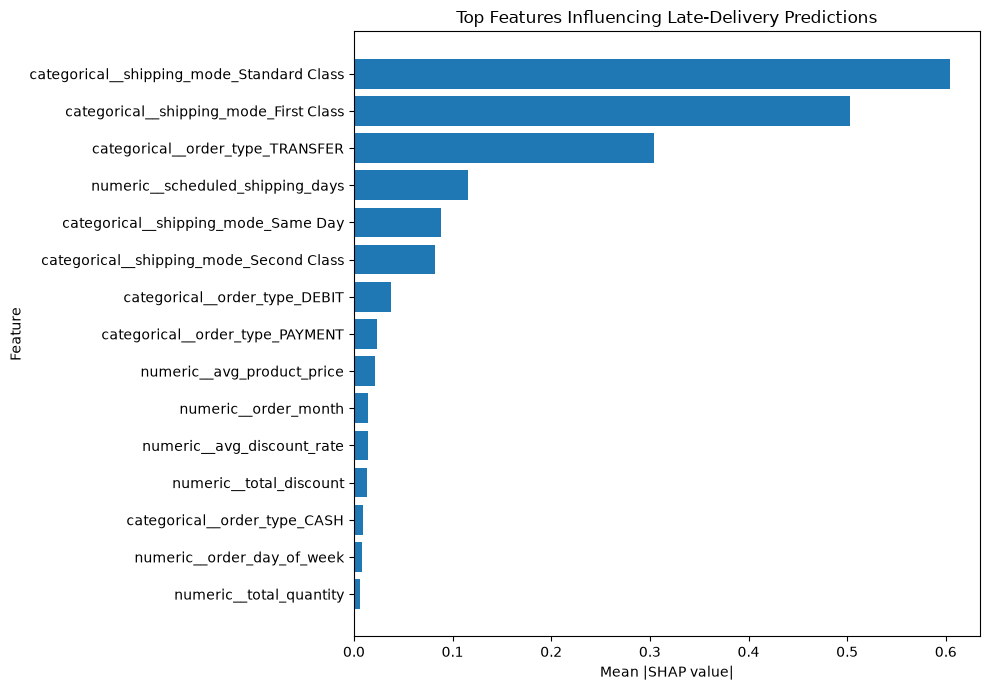

In [67]:
import matplotlib.pyplot as plt

top_shap = shap_importance.head(15).sort_values(
    "mean_abs_shap"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_shap["feature"],
    top_shap["mean_abs_shap"]
)

plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title("Top Features Influencing Late-Delivery Predictions")

plt.tight_layout()
plt.show()

In [68]:
import numpy as np
import pandas as pd

# Get encoded feature names
feature_names = xgb_preprocessor.get_feature_names_out()

# Mean absolute SHAP value for each encoded feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Create SHAP importance dataframe
shap_df = pd.DataFrame({
    "encoded_feature": feature_names,
    "mean_abs_shap": mean_abs_shap
})


def get_original_feature(encoded_name):
    """
    Convert encoded feature names back to
    their original feature names.
    """

    # Remove sklearn transformer prefix
    name = encoded_name.replace("categorical__", "")
    name = name.replace("numeric__", "")

    # Match against original model features
    for feature in model_features:

        if name == feature:
            return feature

        if name.startswith(feature + "_"):
            return feature

    return name


shap_df["original_feature"] = (
    shap_df["encoded_feature"]
    .apply(get_original_feature)
)

original_shap = (
    shap_df
    .groupby("original_feature")["mean_abs_shap"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

original_shap.columns = [
    "feature",
    "mean_abs_shap"
]

original_shap

,feature,mean_abs_shap
0,shipping_mode,1.277411
1,order_type,0.374574
2,scheduled_shipping_days,0.115824
3,order_city,0.042080
4,order_state,0.033140
5,avg_product_price,0.021427
6,order_country,0.019645
7,order_month,0.014690
8,avg_discount_rate,0.014261
9,total_discount,0.013654


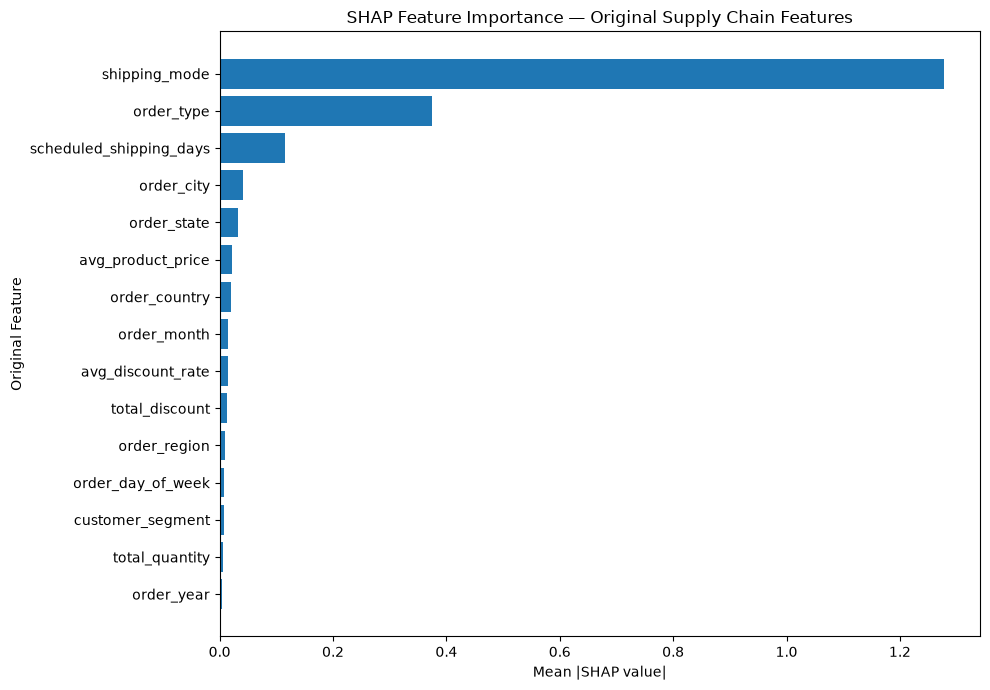

In [69]:
import matplotlib.pyplot as plt

top_original = (
    original_shap
    .head(15)
    .sort_values("mean_abs_shap")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_original["feature"],
    top_original["mean_abs_shap"]
)

plt.xlabel("Mean |SHAP value|")
plt.ylabel("Original Feature")
plt.title(
    "SHAP Feature Importance — Original Supply Chain Features"
)

plt.tight_layout()
plt.show()

In [70]:
# Find an actual test order with a high predicted probability

prediction_results = X_test.copy()

prediction_results["actual"] = y_test.values
prediction_results["predicted_probability"] = xgb_prob
prediction_results["predicted_class"] = xgb_pred

high_risk_orders = prediction_results.sort_values(
    "predicted_probability",
    ascending=False
)

high_risk_orders.head(10)

,order_type,market,order_city,order_country,order_region,order_state,shipping_mode,scheduled_shipping_days,customer_segment,item_count,...,total_quantity,avg_product_price,total_discount,avg_discount_rate,order_year,order_month,order_day_of_week,actual,predicted_probability,predicted_class
64741,DEBIT,Pacific Asia,Seúl,Corea del Sur,Eastern Asia,Seúl,First Class,1,Home Office,1,...,1,11.540000,1.150000,0.10,2018,1,2,1,0.997571,1
63803,DEBIT,Pacific Asia,Seúl,Corea del Sur,Eastern Asia,Seúl,First Class,1,Consumer,1,...,1,293.040008,2.930000,0.01,2018,1,2,1,0.997489,1
63757,DEBIT,Pacific Asia,Changchun,China,Eastern Asia,Jilin,First Class,1,Consumer,1,...,1,293.040008,38.099998,0.13,2018,1,1,1,0.997477,1
63802,DEBIT,Pacific Asia,Seúl,Corea del Sur,Eastern Asia,Seúl,First Class,1,Consumer,1,...,1,293.040008,5.860000,0.02,2018,1,2,1,0.997438,1
64500,PAYMENT,Pacific Asia,Wuxi,China,Eastern Asia,Hunan,First Class,1,Home Office,1,...,1,11.540000,2.310000,0.20,2018,1,5,1,0.997399,1
65109,DEBIT,Pacific Asia,Marikina,Filipinas,Southeast Asia,Capital Nacional,First Class,1,Consumer,1,...,1,39.750000,0.800000,0.02,2018,1,0,1,0.997367,1
63860,PAYMENT,Pacific Asia,Melbourne,Australia,Oceania,Victoria,First Class,1,Corporate,1,...,1,210.850006,33.740002,0.16,2018,1,3,1,0.997348,1
65056,DEBIT,Pacific Asia,Jalalabad,Afganistán,South Asia,Nangarhar,First Class,1,Home Office,1,...,1,39.750000,0.400000,0.01,2018,1,6,1,0.997336,1
65684,PAYMENT,Pacific Asia,Aurangabad,India,South Asia,Bihar,First Class,1,Corporate,1,...,1,215.820007,19.420000,0.09,2018,1,2,1,0.997315,1
64526,DEBIT,Pacific Asia,Jiangyou,China,Eastern Asia,Sichuan,First Class,1,Consumer,1,...,1,11.540000,1.040000,0.09,2018,1,6,1,0.997294,1


In [71]:
selected_order_id = high_risk_orders.index[0]

print("Selected test row:", selected_order_id)
print(
    "Predicted probability:",
    round(
        high_risk_orders.loc[
            selected_order_id,
            "predicted_probability"
        ],
        4
    )
)

print(
    "Actual outcome:",
    high_risk_orders.loc[
        selected_order_id,
        "actual"
    ]
)

Selected test row: 64741
Predicted probability: 0.9976
Actual outcome: 1


In [72]:
# Get the original feature row
selected_raw = X_test.loc[[selected_order_id]]

# Transform it using the fitted XGBoost preprocessing pipeline
selected_transformed = xgb_preprocessor.transform(selected_raw)

# Calculate SHAP values for this order
selected_shap = explainer.shap_values(selected_transformed)

print("SHAP calculation completed.")
print("Number of SHAP features:", selected_shap.shape[1])

SHAP calculation completed.
Number of SHAP features: 3309


In [73]:
# Create a dataframe containing the feature-level SHAP contributions

individual_shap = pd.DataFrame({
    "feature": feature_names,
    "shap_value": selected_shap[0],
    "abs_shap": np.abs(selected_shap[0])
})

individual_shap = (
    individual_shap
    .sort_values("abs_shap", ascending=False)
    .reset_index(drop=True)
)

individual_shap.head(20)

,feature,shap_value,abs_shap
0,categorical__shipping_mode_First Class,2.780417,2.780417
1,categorical__order_type_TRANSFER,1.041835,1.041835
2,categorical__shipping_mode_Standard Class,1.014982,1.014982
3,categorical__order_type_DEBIT,0.259795,0.259795
4,numeric__scheduled_shipping_days,0.228442,0.228442
5,categorical__shipping_mode_Second Class,0.144287,0.144287
6,categorical__shipping_mode_Same Day,0.102370,0.102370
7,categorical__order_country_Corea del Sur,0.100337,0.100337
8,numeric__total_discount,0.047124,0.047124
9,categorical__order_city_Seúl,0.032380,0.032380


In [75]:
# Convert the transformed single-order row to a 1D array
if hasattr(selected_transformed, "toarray"):
    selected_data = selected_transformed.toarray().ravel()
else:
    selected_data = np.asarray(selected_transformed).ravel()

# Make sure SHAP values are also 1D
selected_values = np.asarray(selected_shap).ravel()

# Get the expected/base value
base_value = explainer.expected_value

if isinstance(base_value, (list, np.ndarray)):
    base_value = np.asarray(base_value).ravel()[0]

print("SHAP values:", selected_values.shape)
print("Feature data:", selected_data.shape)
print("Feature names:", len(feature_names))
print("Base value:", base_value)

SHAP values: (3309,)
Feature data: (3309,)
Feature names: 3309
Base value: 0.19608922


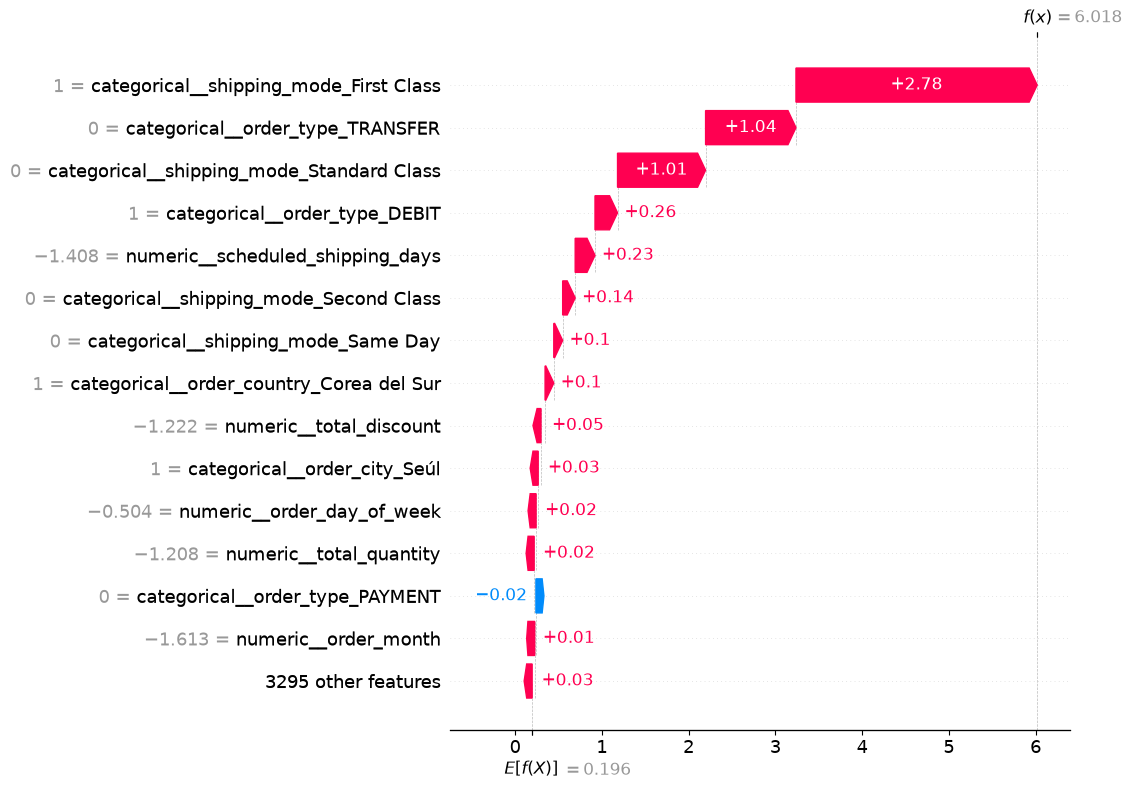

In [76]:
selected_explanation = shap.Explanation(
    values=selected_values,
    base_values=base_value,
    data=selected_data,
    feature_names=feature_names
)

shap.plots.waterfall(
    selected_explanation,
    max_display=15
)

In [77]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    xgb_model,
    "../models/xgboost_late_delivery_model.pkl"
)

joblib.dump(
    model_features,
    "../models/model_features.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [79]:
def predict_delivery_risk(order_data):
    """
    Predict late-delivery risk for a single order.
    """

    # Convert input dictionary into DataFrame
    input_df = pd.DataFrame([order_data])

    # Ensure feature order is exactly the same as training
    input_df = input_df[model_features]

    # Predict probability
    probability = xgb_model.predict_proba(input_df)[0, 1]

    # Predict class
    prediction = xgb_model.predict(input_df)[0]

    # Convert probability into risk level
    if probability >= 0.70:
        risk = "HIGH"
    elif probability >= 0.40:
        risk = "MEDIUM"
    else:
        risk = "LOW"

    return {
        "prediction": int(prediction),
        "probability": probability,
        "risk": risk
    }

print("Prediction function created successfully.")

Prediction function created successfully.


In [80]:
test_order = X_test.iloc[0].to_dict()

prediction_result = predict_delivery_risk(test_order)

print("Prediction:", prediction_result["prediction"])
print(
    "Late-delivery probability:",
    round(prediction_result["probability"] * 100, 2),
    "%"
)
print("Risk level:", prediction_result["risk"])

Prediction: 1
Late-delivery probability: 71.44 %
Risk level: HIGH


In [81]:
actual_value = y_test.iloc[0]

print("Actual outcome:", actual_value)
print("Predicted outcome:", prediction_result["prediction"])

if actual_value == prediction_result["prediction"]:
    print("Prediction: CORRECT")
else:
    print("Prediction: INCORRECT")

Actual outcome: 1
Predicted outcome: 1
Prediction: CORRECT


In [82]:
import joblib
import numpy as np
import pandas as pd
import shap

# Load saved model and feature list
loaded_model = joblib.load(
    "../models/xgboost_late_delivery_model.pkl"
)

loaded_features = joblib.load(
    "../models/model_features.pkl"
)

# Extract preprocessing and XGBoost components
loaded_preprocessor = loaded_model.named_steps["preprocessor"]
loaded_classifier = loaded_model.named_steps["classifier"]

# Get encoded feature names
loaded_feature_names = (
    loaded_preprocessor.get_feature_names_out()
)

print("Saved model loaded successfully.")
print("Number of original features:", len(loaded_features))
print("Number of encoded features:", len(loaded_feature_names))

Saved model loaded successfully.
Number of original features: 18
Number of encoded features: 3309


In [83]:
def predict_and_explain(order_data, top_n=8):

    # -----------------------------
    # 1. Prepare input
    # -----------------------------
    input_df = pd.DataFrame([order_data])

    # Make sure feature order matches training
    input_df = input_df[loaded_features]

    # -----------------------------
    # 2. Prediction
    # -----------------------------
    prediction = int(
        loaded_model.predict(input_df)[0]
    )

    probability = float(
        loaded_model.predict_proba(input_df)[0, 1]
    )

    # Risk classification
    if probability >= 0.70:
        risk = "HIGH"
    elif probability >= 0.40:
        risk = "MEDIUM"
    else:
        risk = "LOW"

    # -----------------------------
    # 3. Transform input for SHAP
    # -----------------------------
    transformed_input = loaded_preprocessor.transform(
        input_df
    )

    # Convert sparse matrix to 1D array
    if hasattr(transformed_input, "toarray"):
        shap_data = transformed_input.toarray().ravel()
    else:
        shap_data = np.asarray(
            transformed_input
        ).ravel()

    # -----------------------------
    # 4. Calculate SHAP values
    # -----------------------------
    explainer = shap.TreeExplainer(
        loaded_classifier
    )

    shap_values = explainer.shap_values(
        transformed_input
    )

    shap_values = np.asarray(
        shap_values
    ).ravel()

    # -----------------------------
    # 5. Create SHAP dataframe
    # -----------------------------
    shap_df = pd.DataFrame({
        "encoded_feature": loaded_feature_names,
        "shap_value": shap_values
    })

    # -----------------------------
    # 6. Map encoded features
    #    back to original features
    # -----------------------------
    def get_original_feature(name):

        name = name.replace(
            "categorical__", ""
        )

        name = name.replace(
            "numeric__", ""
        )

        for feature in loaded_features:

            if name == feature:
                return feature

            if name.startswith(
                feature + "_"
            ):
                return feature

        return name

    shap_df["original_feature"] = (
        shap_df["encoded_feature"]
        .apply(get_original_feature)
    )

    # -----------------------------
    # 7. Aggregate SHAP values
    # -----------------------------
    feature_explanations = (
        shap_df
        .groupby("original_feature")["shap_value"]
        .sum()
        .sort_values(
            ascending=False
        )
    )

    positive_factors = (
        feature_explanations[
            feature_explanations > 0
        ]
        .head(top_n)
    )

    negative_factors = (
        feature_explanations[
            feature_explanations < 0
        ]
        .sort_values()
        .head(top_n)
    )

    return {
        "prediction": prediction,
        "probability": probability,
        "risk": risk,
        "positive_factors": positive_factors,
        "negative_factors": negative_factors,
        "shap_values": shap_df
    }


print("Predict + Explain function created successfully.")

Predict + Explain function created successfully.


In [84]:
result = predict_and_explain(
    test_order,
    top_n=8
)

print("===================================")
print("AI SUPPLY CHAIN RISK PREDICTION")
print("===================================")

print(
    "Prediction:",
    result["prediction"]
)

print(
    "Late probability:",
    round(
        result["probability"] * 100,
        2
    ),
    "%"
)

print(
    "Risk:",
    result["risk"]
)

print("\nPositive contributing factors:")
print(
    result["positive_factors"]
)

print("\nNegative contributing factors:")
print(
    result["negative_factors"]
)

AI SUPPLY CHAIN RISK PREDICTION
Prediction: 1
Late probability: 71.44 %
Risk: HIGH

Positive contributing factors:
original_feature
shipping_mode              1.975438
scheduled_shipping_days    0.157791
avg_product_price          0.041314
order_month                0.017525
total_quantity             0.017388
market                     0.015145
distinct_product_count     0.009285
order_region               0.004207
Name: shap_value, dtype: float32

Negative contributing factors:
original_feature
order_type          -1.128429
order_day_of_week   -0.106713
order_country       -0.092985
total_discount      -0.080635
avg_discount_rate   -0.052227
order_city          -0.028765
order_year          -0.020462
customer_segment    -0.006898
Name: shap_value, dtype: float32


In [85]:
original_result = predict_delivery_risk(
    test_order
)

saved_result = predict_and_explain(
    test_order
)

print("Original model probability:",
      round(
          original_result["probability"],
          6
      ))

print("Saved model probability:",
      round(
          saved_result["probability"],
          6
      ))

print(
    "\nSame prediction:",
    original_result["prediction"]
    == saved_result["prediction"]
)

Original model probability: 0.714389
Saved model probability: 0.714389

Same prediction: True
